In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(PROJECT_ROOT)

d:\Property Intelligence Platform


In [2]:
import numpy as np
import pandas as pd
import re

In [3]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


In [4]:
from src.data.ingestion import load_data

df = load_data("../data/cleaned/gurgaon_properties_cleaned_v1.csv")

Dataset loaded successfully.
Rows: 3803
Columns: 17


In [5]:
df.duplicated().sum()

np.int64(122)

In [6]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
2815,2.98,1449.0,Plot area 161(134.62 sq.m.)
3155,1.65,2125.0,Super Built up area 2125(197.42 sq.m.)
242,2.40,1380.0,Super Built up area 1380(128.21 sq.m.)Built Up area: 1200 sq.ft. (111.48 sq.m.)Carpet area: 900 sq.ft. (83.61 sq.m.)
3780,1.68,2545.0,Super Built up area 2545(236.44 sq.m.)
1794,1.60,1745.0,Super Built up area 1745(162.12 sq.m.)Built Up area: 1550 sq.ft. (144 sq.m.)


In [7]:
# This function extracts the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [8]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [9]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [10]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

In [11]:
# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

In [12]:
# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [13]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3653,2.25,house,1332.0,Built Up area: 148 (123.75 sq.m.),NaN,148.0,NaN
2264,1.55,flat,1950.0,Super Built up area 1950(181.16 sq.m.)Carpet area: 1161 sq.ft. (107.86 sq.m.),1950.0,NaN,1161.0
2969,2.60,flat,3150.0,Super Built up area 3150(292.64 sq.m.),3150.0,NaN,NaN
3685,1.28,flat,1560.0,Super Built up area 1930(179.3 sq.m.)Carpet area: 1560 sq.ft. (144.93 sq.m.),1930.0,NaN,1560.0
500,2.25,flat,2585.0,Super Built up area 2585(240.15 sq.m.),2585.0,NaN,NaN


In [14]:
# Built up area, Carpet area and Super Built up area are all available
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

In [15]:
# extract rows with plot area 
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2,8.00,house,7000.0,Plot area 7000(650.32 sq.m.),NaN,NaN,NaN
4,4.50,house,1845.0,Plot area 204(170.57 sq.m.)Built Up area: 206 sq.yards (172.24 sq.m.)Carpet area: 205 sq.yards (171.41 sq.m.),NaN,206.0,205.0
6,25.00,house,8036.0,Plot area 1000(836.13 sq.m.),NaN,NaN,NaN
8,5.65,house,2367.0,Plot area 263(219.9 sq.m.),NaN,NaN,NaN
13,1.50,house,1426.0,Plot area 1426(132.48 sq.m.),NaN,NaN,NaN


In [16]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2616
carpet_area            1859
dtype: int64

In [17]:
# extract rows with null in super built up area, built up area and carpet area
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [18]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2,8.00,house,7000.0,Plot area 7000(650.32 sq.m.),NaN,NaN,NaN
6,25.00,house,8036.0,Plot area 1000(836.13 sq.m.),NaN,NaN,NaN
8,5.65,house,2367.0,Plot area 263(219.9 sq.m.),NaN,NaN,NaN
13,1.50,house,1426.0,Plot area 1426(132.48 sq.m.),NaN,NaN,NaN
18,5.60,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN


In [19]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [20]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [21]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

In [22]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2,8.00,house,7000.0,Plot area 7000(650.32 sq.m.),NaN,7000.00,NaN
6,25.00,house,8036.0,Plot area 1000(836.13 sq.m.),NaN,1000.00,NaN
8,5.65,house,2367.0,Plot area 263(219.9 sq.m.),NaN,263.00,NaN
13,1.50,house,1426.0,Plot area 1426(132.48 sq.m.),NaN,1426.00,NaN
18,5.60,house,2700.0,Plot area 300(250.84 sq.m.),NaN,300.00,NaN
40,7.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.00,NaN
51,19.00,house,4518.0,Plot area 502(419.74 sq.m.),NaN,502.00,NaN
62,4.60,house,2610.0,Plot area 290(242.48 sq.m.),NaN,290.00,NaN
70,5.60,house,4000.0,Plot area 4000(371.61 sq.m.),NaN,4000.00,NaN
72,3.55,house,1449.0,Plot area 161(134.62 sq.m.),NaN,161.00,NaN


In [23]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [24]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [25]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2,8.00,house,7000.0,Plot area 7000(650.32 sq.m.),NaN,7000.00,NaN
6,25.00,house,8036.0,Plot area 1000(836.13 sq.m.),NaN,1000.00,NaN
8,5.65,house,2367.0,Plot area 263(219.9 sq.m.),NaN,2367.00,NaN
13,1.50,house,1426.0,Plot area 1426(132.48 sq.m.),NaN,1426.00,NaN
18,5.60,house,2700.0,Plot area 300(250.84 sq.m.),NaN,2700.00,NaN
40,7.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.00,NaN
51,19.00,house,4518.0,Plot area 502(419.74 sq.m.),NaN,4518.00,NaN
62,4.60,house,2610.0,Plot area 290(242.48 sq.m.),NaN,2610.00,NaN
70,5.60,house,4000.0,Plot area 4000(371.61 sq.m.),NaN,4000.00,NaN
72,3.55,house,1449.0,Plot area 161(134.62 sq.m.),NaN,1449.00,NaN


In [26]:
# update the original dataframe
df.update(all_nan_df)

In [27]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2070
carpet_area            1859
dtype: int64

In [28]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
0,house,sare crescent parc royal greens phase 1,sector 92,0.85,4877.0,1743.0,Built Up area: 1743 (161.93 sq.m.),4,4,3,not available,4.0,NaN,undefined,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. Sarkar Clinic', 'Vijay Petrol Pump', 'HP Petrol Pump', 'Indian Oil', 'Essar Petrol Pump', 'Garhi harsaru junction railway station']","['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN,NaN,1743.0,NaN
1,flat,sare green parc phase 3,sector 92,1.08,5150.0,2097.0,Super Built up area 2090(194.17 sq.m.),4,4,2,servant room,16.0,NaN,0 to 1 Year Old,"['Huda Metro Station', 'Sector Road', 'Delhi-Jaipur Expressway', 'Management Development Institute', 'Ajanta Public School', 'The NorthCap University', 'Fortis Memorial Research Institute', 'Indira Gandhi Intl Airport', 'Signature Towers', 'Crowne Plaza Gurgaon', 'Kingdom of Dreams']",NaN,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']",2090.0,NaN,NaN
2,house,unitech uniworld resorts,sector 33,8.00,11428.0,7000.0,Plot area 7000(650.32 sq.m.),4,4,3+,"pooja room,servant room,study room,store room",2.0,West,10+ Year Old,"['Rajiv Chowk Mosque', 'Icici bank ATM', 'Standard chartered ATM', 'Samvit Health Care', 'Airforce Hospital', 'Medanta', ""DR AKRAM JAWED'S THE UPPER LIMB CLINIC"", 'Sukhmani Hospital Pvt. Ltd', 'Vaishnavi Nursing Home', 'Best Urologist Atcomplete Family Clinic', 'Ayushman Hospital And Trauma Centre', 'Park Hospital Gurgaon', 'Wellness Eye Centre', 'Neelkanth Health Care', 'Dr. Aruna Kalra', 'Vishesh Dental', 'Smile Plus Dental Clinic', 'Dr. Anuj Sharma', 'Dr. Naresh Pandita', 'Bansal Medicare and Maternity Centre', 'Pushpanjali Hospital Gurgaon', 'Shri Ram Dental Clinic', 'Sunrise Hospital Gurgaon', 'Meher Clinic', 'Rajendra Hospital', 'Pushpanjali Hospital', 'Sai Dental Clinic', 'Nutan Dental Hospital', 'Parmar Dental Clinic & Lab', 'Road and Traffic Authority', 'Gurgaon Election Commission', 'Apollo Pharmacy', 'Gardian Pharmacy', 'Genius', 'India Oil', 'SRS Cinemas', 'SRS Cinemas', 'Hdfc bank', 'Icici bank', 'Hdfc bank', 'KFC', 'Haldiram', ""Domino's Pizza"", ""Nirula's"", 'Kendriya Vidyalaya No.2 Sohna Road', 'Delhi Public School Primary Section']",NaN,"['Private Garden / Terrace', 'False Ceiling Lighting', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Low Density Society', 'Fitness Centre / GYM', 'Club house / Community Center']",NaN,7000.0,NaN
3,flat,ireo the corridors,sector 67a,1.60,9264.0,1727.0,Super Built up area 1727(160.44 sq.m.)Carpet area: 1017 sq.ft. (94.48 sq.m.),3,3,2,store room,3.0,North,0 to 1 Year Old,"['Huda Metro Station (Gurugram)', 'Paras Trinity Mall', 'Southern Peripheral Road', 'Lovely Public School', 'KIIT College of Engineering', 'Indira Gandhi International Airport', 'AIPL Business Centre', 'Lemon Tree Hotel, Sohna Road', 'Radisson Hotel', 'De Adventure Park', 'Teri Golf Course', 'PVR Drive in Theatre']","['3 Wardrobe', '1 Water Purifier', '4 Fan', '1 Exhaust Fan', '3 Geyser', '4 Light', '1 Modular Kitchen', '1 Chimney', '1 Curtains', '4 AC', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wa

### 2.additionalRoom

In [29]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1587
servant room                                      705
study room                                        250
others                                            225
pooja room                                        165
study room,servant room                            99
store room                                         99
pooja room,servant room                            82
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 55
pooja room,study room,servant room,others          54
servant room,pooja room                            38
servant room,store room                            33
study room,others                                  29
pooja room,study room                              22
pooja room,others                                  17
pooja room,store room                              15
servant room,

In [30]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [35]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
3088,not available,0,0,0,0,0
3596,store room,0,0,1,0,0
2822,"study room,pooja room,servant room",1,1,0,1,0
2305,servant room,0,1,0,0,0
1313,study room,1,0,0,0,0


In [36]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,house,sare crescent parc royal greens phase 1,sector 92,0.85,4877.0,1743.0,Built Up area: 1743 (161.93 sq.m.),4,4,3,not available,4.0,NaN,undefined,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. Sarkar Clinic', 'Vijay Petrol Pump', 'HP Petrol Pump', 'Indian Oil', 'Essar Petrol Pump', 'Garhi harsaru junction railway station']","['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN,NaN,1743.0,NaN,0,0,0,0,0
1,flat,sare green parc phase 3,sector 92,1.08,5150.0,2097.0,Super Built up area 2090(194.17 sq.m.),4,4,2,servant room,16.0,NaN,0 to 1 Year Old,"['Huda Metro Station', 'Sector Road', 'Delhi-Jaipur Expressway', 'Management Development Institute', 'Ajanta Public School', 'The NorthCap University', 'Fortis Memorial Research Institute', 'Indira Gandhi Intl Airport', 'Signature Towers', 'Crowne Plaza Gurgaon', 'Kingdom of Dreams']",NaN,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']",2090.0,NaN,NaN,0,1,0,0,0
2,house,unitech uniworld resorts,sector 33,8.00,11428.0,7000.0,Plot area 7000(650.32 sq.m.),4,4,3+,"pooja room,servant room,study room,store room",2.0,West,10+ Year Old,"['Rajiv Chowk Mosque', 'Icici bank ATM', 'Standard chartered ATM', 'Samvit Health Care', 'Airforce Hospital', 'Medanta', ""DR AKRAM JAWED'S THE UPPER LIMB CLINIC"", 'Sukhmani Hospital Pvt. Ltd', 'Vaishnavi Nursing Home', 'Best Urologist Atcomplete Family Clinic', 'Ayushman Hospital And Trauma Centre', 'Park Hospital Gurgaon', 'Wellness Eye Centre', 'Neelkanth Health Care', 'Dr. Aruna Kalra', 'Vishesh Dental', 'Smile Plus Dental Clinic', 'Dr. Anuj Sharma', 'Dr. Naresh Pandita', 'Bansal Medicare and Maternity Centre', 'Pushpanjali Hospital Gurgaon', 'Shri Ram Dental Clinic', 'Sunrise Hospital Gurgaon', 'Meher Clinic', 'Rajendra Hospital', 'Pushpanjali Hospital', 'Sai Dental Clinic', 'Nutan Dental Hospital', 'Parmar Dental Clinic & Lab', 'Road and Traffic Authority', 'Gurgaon Election Commission', 'Apollo Pharmacy', 'Gardian Pharmacy', 'Genius', 'India Oil', 'SRS Cinemas', 'SRS Cinemas', 'Hdfc bank', 'Icici bank', 'Hdfc bank', 'KFC', 'Haldiram', ""Domino's Pizza"", ""Nirula's"", 'Kendriya Vidyalaya No.2 Sohna Road', 'Delhi Public School Primary Section']",NaN,"['Private Garden / Terrace', 'False Ceiling Lighting', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Low Density Society', 'Fitness Centre / GYM', 'Club house / Community Center']",NaN,7000.0,NaN,1,1,1,1,0
3,flat,ireo the corridors,sector 67a,1.60,9264.0,1727.0,Super Built up area 1727(160.44 sq.m.)Carpet area: 1017 sq.ft. (94.48 sq.m.),3,3,2,store room,3.0,North,0 to 1 Year Old,"['Huda Metro Station (Gurugram)', 'Paras Trinity Mall', 'Southern Peripheral Road', 'Lovely Public School', 'KIIT College of Engineering', 'Indira Gandhi International Airport', 'AIPL Business Centre', 'Lemon Tree Hotel, Sohna Road', 'Radisson Hotel', 'De Adventure Park', 'Teri Golf Course', 'PVR Drive in Theatre']","['3 Wardrobe', '1 Water Purifier', '4 Fan', '1 Exhaust Fan', '3 Geyser', '4 Light', '1 Modular Kitchen', '1 Chimney', '1 Curtains', '4 AC', 'No Bed', 'No

### 3.agePossession

In [37]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1676
5 to 10 Year Old       575
0 to 1 Year Old        530
undefined              332
10+ Year Old           310
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Jan 2024                 8
Oct 2024                 8
Dec 2025                 7
Aug 2023                 7
Jun 2024                 7
Nov 2023                 5
Aug 2024                 4
By 2025                  4
Jul 2024                 4
Sep 2023                 4
Oct 2023                 4
Jan 2025                 3
Nov 2024                 3
May 2024                 3
Feb 2024                 3
Sep 2025                 2
Jan 2026                 2
Jul 2025                 2
Dec 2026                 2
Oct 2025                 2
Jun 2027                 2
By 2027                  2
Apr 2026                 2
Aug 2025      

In [38]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [39]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [40]:
df['agePossession'].value_counts()

agePossession
Relatively New        1676
New Property           626
Moderately Old         575
Undefined              333
Old Property           310
Under Construction     283
Name: count, dtype: int64

In [41]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,house,sare crescent parc royal greens phase 1,sector 92,0.85,4877.0,1743.0,Built Up area: 1743 (161.93 sq.m.),4,4,3,not available,4.0,NaN,Undefined,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. Sarkar Clinic', 'Vijay Petrol Pump', 'HP Petrol Pump', 'Indian Oil', 'Essar Petrol Pump', 'Garhi harsaru junction railway station']","['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN,NaN,1743.0,NaN,0,0,0,0,0
1,flat,sare green parc phase 3,sector 92,1.08,5150.0,2097.0,Super Built up area 2090(194.17 sq.m.),4,4,2,servant room,16.0,NaN,New Property,"['Huda Metro Station', 'Sector Road', 'Delhi-Jaipur Expressway', 'Management Development Institute', 'Ajanta Public School', 'The NorthCap University', 'Fortis Memorial Research Institute', 'Indira Gandhi Intl Airport', 'Signature Towers', 'Crowne Plaza Gurgaon', 'Kingdom of Dreams']",NaN,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']",2090.0,NaN,NaN,0,1,0,0,0
2,house,unitech uniworld resorts,sector 33,8.00,11428.0,7000.0,Plot area 7000(650.32 sq.m.),4,4,3+,"pooja room,servant room,study room,store room",2.0,West,Old Property,"['Rajiv Chowk Mosque', 'Icici bank ATM', 'Standard chartered ATM', 'Samvit Health Care', 'Airforce Hospital', 'Medanta', ""DR AKRAM JAWED'S THE UPPER LIMB CLINIC"", 'Sukhmani Hospital Pvt. Ltd', 'Vaishnavi Nursing Home', 'Best Urologist Atcomplete Family Clinic', 'Ayushman Hospital And Trauma Centre', 'Park Hospital Gurgaon', 'Wellness Eye Centre', 'Neelkanth Health Care', 'Dr. Aruna Kalra', 'Vishesh Dental', 'Smile Plus Dental Clinic', 'Dr. Anuj Sharma', 'Dr. Naresh Pandita', 'Bansal Medicare and Maternity Centre', 'Pushpanjali Hospital Gurgaon', 'Shri Ram Dental Clinic', 'Sunrise Hospital Gurgaon', 'Meher Clinic', 'Rajendra Hospital', 'Pushpanjali Hospital', 'Sai Dental Clinic', 'Nutan Dental Hospital', 'Parmar Dental Clinic & Lab', 'Road and Traffic Authority', 'Gurgaon Election Commission', 'Apollo Pharmacy', 'Gardian Pharmacy', 'Genius', 'India Oil', 'SRS Cinemas', 'SRS Cinemas', 'Hdfc bank', 'Icici bank', 'Hdfc bank', 'KFC', 'Haldiram', ""Domino's Pizza"", ""Nirula's"", 'Kendriya Vidyalaya No.2 Sohna Road', 'Delhi Public School Primary Section']",NaN,"['Private Garden / Terrace', 'False Ceiling Lighting', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Low Density Society', 'Fitness Centre / GYM', 'Club house / Community Center']",NaN,7000.0,NaN,1,1,1,1,0
3,flat,ireo the corridors,sector 67a,1.60,9264.0,1727.0,Super Built up area 1727(160.44 sq.m.)Carpet area: 1017 sq.ft. (94.48 sq.m.),3,3,2,store room,3.0,North,New Property,"['Huda Metro Station (Gurugram)', 'Paras Trinity Mall', 'Southern Peripheral Road', 'Lovely Public School', 'KIIT College of Engineering', 'Indira Gandhi International Airport', 'AIPL Business Centre', 'Lemon Tree Hotel, Sohna Road', 'Radisson Hotel', 'De Adventure Park', 'Teri Golf Course', 'PVR Drive in Theatre']","['3 Wardrobe', '1 Water Purifier', '4 Fan', '1 Exhaust Fan', '3 Geyser', '4 Light', '1 Modular Kitchen', '1 Chimney', '1 Curtains', '4 AC', 'No Bed', 'No Dinin

In [42]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
1368,"['6 Fan', '8 Light', '1 Chimney', '1 Modular Kitchen', '6 AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Power Back-up', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Separate entry for servant room', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Water softening plant']"
254,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
798,[],"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center']"
775,"['6 Wardrobe', '1 Water Purifier', '8 Fan', '1 Exhaust Fan', '6 Geyser', '28 Light', '6 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Water purifier', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"
1496,"['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Lift(s)', 'Swimming Pool', 'Water Storage', 'Park']"


In [43]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [45]:
furnishings_df.shape

(3803, 19)

In [46]:
furnishings_df.sample(5)

,furnishDetails,Geyser,Wardrobe,Light,Sofa,Exhaust Fan,Dining Table,Bed,Fan,Modular Kitchen,Curtains,Microwave,Chimney,AC,TV,Stove,Washing Machine,Water Purifier,Fridge
1199,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3438,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1107,"['1 Wardrobe', '1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3142,"['6 Fan', '20 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0,0,20,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0
571,"['1 Fan', '1 Exhaust Fan', '1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0


In [47]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_16480\114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [48]:
furnishings_df.sample(5)

,Geyser,Wardrobe,Light,Sofa,Exhaust Fan,Dining Table,Bed,Fan,Modular Kitchen,Curtains,Microwave,Chimney,AC,TV,Stove,Washing Machine,Water Purifier,Fridge
3655,2,2,5,0,1,0,0,5,1,0,0,0,0,0,0,0,0,0
2855,9,9,0,0,1,0,0,21,1,0,0,3,10,0,0,0,0,0
12,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2204,1,2,8,0,1,0,0,6,1,1,0,1,6,0,0,0,0,0
1606,2,2,4,0,0,0,0,3,0,0,0,1,0,0,0,0,0,0


In [49]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [50]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [51]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

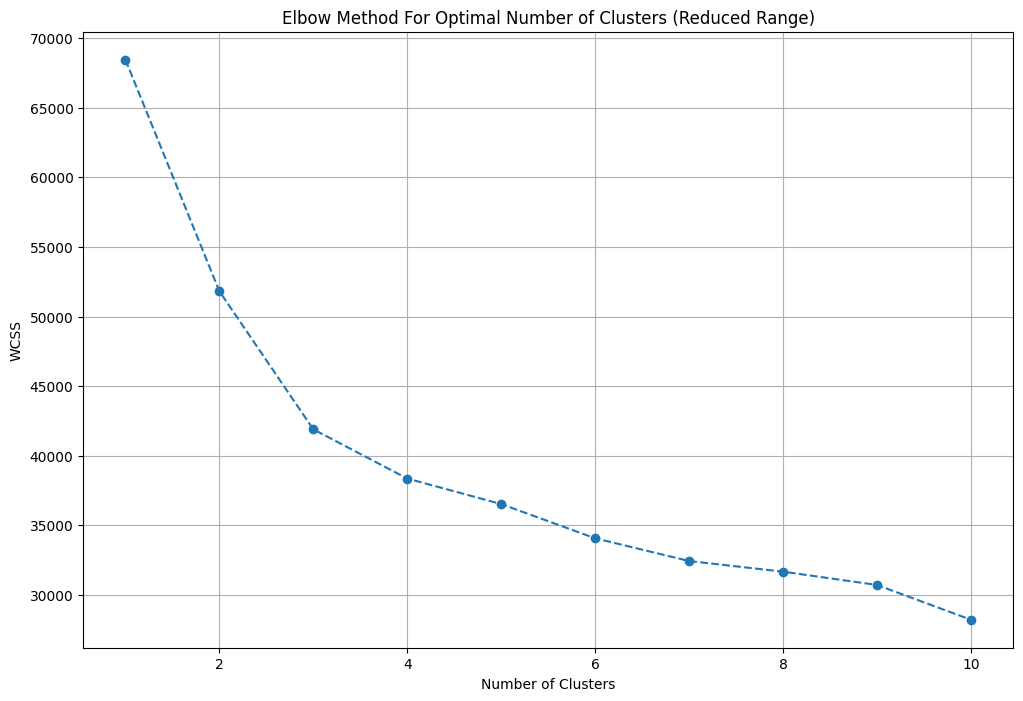

In [53]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [54]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [55]:
df = df.iloc[:,:-18]

In [56]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
80,flat,raheja vedaanta,sector 108,1.00,4854.0,2060.0,Built Up area: 2060 (191.38 sq.m.)Carpet area: 1890 sq.ft. (175.59 sq.m.),2,2,2,not available,0.0,North,Undefined,NaN,NaN,NaN,NaN,2060.0,1890.0,0,0,0,0,0
758,house,independent,sector 7,1.00,79365.0,126.0,Plot area 126(11.71 sq.m.),2,2,0,study room,0.0,NaN,Old Property,"['State bank ATM', 'Dr. Madan Clinic', 'Taneja Hospital', 'Dev Man Kathuria Clinic', 'Pearl Dental Clinic', 'Shiv Mahima Patient Care Bureau', 'Ankur Clinic and Maternity Home', 'Navjeevan Hospital and Maternity Centre', 'Satyam Hospital Gurgaon', 'Shri Gobind Hospital', 'Chiranjiv Hospital', 'Lal Superspeciality Hospital', 'Swastik Maternity and Medical Centre', 'Dr. Ashok Jain', 'Geeta Nursing Home Gurgaon', 'Mangalam Hospital and Heart Centre Gurgaon', 'My Care Clinic', 'Bindal Clinic', 'M.S Hospital', 'Triveni Hospital Gurgaon', 'Tirath Ram Hospitals Pvt Ltd', 'Ravi Clinic and Health Care Centre', 'Aryan Hospital', 'Esic Hospital Gurugram', 'Sethi Hospital Gurgaon', 'Shubham Hospital Gurgaon', 'D.R. Rajnis Gupta Clinic', 'Pasricha Hospital and Maternity Home', 'Nangia Hospital Ent and Maternity', 'Kr Dental Hub', 'Parashar Hospital', 'Rama Hospital & Nursing Home', 'Kathuria Hospital', 'Vinayak Hospital Gurgaon', 'Dr. Ajay S. Gupta Clinic', 'Sparsh Hospital Gurgaon', 'Shree Krishna Hospital Gurgaon', 'Gurgaon Eye Centre', 'Bhatnagar Maternity and Nursing Home', 'Gupta Hospital Gurgaon', 'Dr. Sarvejeet Singh', 'Centre For Sight Gurgaon New Railway Road', 'Rachna Dental Clinic', 'State bank of india', 'Hdfc bank', 'Kotak bank', 'Indian bank', 'Pizza Hut', 'St. Michaels Sr. Sec. School', 'Dronacharya Government College']","['1 Fan', '1 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Water Storage', 'Waste Disposal']",NaN,126.0,NaN,1,0,0,0,0
1946,flat,unitech vistas,sector 70,0.53,4800.0,1104.0,Super Built up area 1095(101.73 sq.m.),2,2,2,others,9.0,NaN,Under Construction,"['Airia Mall', 'Delhi Ajmer Highway', 'Sohna Road', 'Suraj School']",[],"['Lift(s)', 'Swimming Pool', 'Park', 'Fitness Centre / GYM']",1095.0,NaN,NaN,0,0,0,0,1
1794,flat,ats kocoon,sector 109,1.60,9169.0,1745.0,Super Built up area 1745(162.12 sq.m.)Built Up area: 1550 sq.ft. (144 sq.m.),3,3,3,not available,10.0,North,Relatively New,"['Jagdish Super Market', 'Dwarka', 'Euro International School', 'Gyaananda School', 'SCR Model School', 'Radha Krishan Mandir', 'ICICI BANK ATM, Annapurna MKT', 'ESIC Dispensary', 'IGIA Airport', 'Canara Bank New Palam Vihar', 'Gurgaon Gramin Bank', 'Daultabad Stadium', 'Bharat Petroleum Shree Shyam Filling', 'The Club, International City', 'Conscient One']","['1 Fan', '1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Club house / Community Center']",1745.0,1550.0,NaN,0,0,0,0,0
1199,flat,sare homes,sector 92,1.19,5219.0,2280.0,Carpet area: 2280 (211.82 sq.m.),4,3,3,servant room,14.0,North,Relatively New,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. Sarkar Clinic', 'Sagar Clinic', 'Vijay Petrol Pump', 'HP Petrol Pump', 'Essar Petrol Pump', 'Indian Oil']",NaN,"['Security / Fire Alarm', 'Feng Shui / V

In [57]:
df['furnishing_type'] = cluster_assignments

In [ ]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
2355,"['1 Water Purifier', '1 Exhaust Fan', '3 Geyser', '5 AC', '1 Chimney', '1 Modular Kitchen', 'No Bed', 'No Curtains', 'No Dining Table', 'No Fan', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine']",1
1465,"['2 Fan', '1 Exhaust Fan', '1 Geyser', '1 Stove', '6 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0
3546,[],0
1141,NaN,0
449,"['6 Fan', '1 Fridge', '1 Exhaust Fan', '1 Dining Table', '5 Geyser', '1 Stove', '5 Light', '1 Modular Kitchen', '1 Curtains', '3 TV', '1 Chimney', '5 AC', '4 Bed', '5 Wardrobe', '1 Sofa', 'No Microwave', 'No Washing Machine', 'No Water Purifier']",2


### features

In [63]:
df[['society','features']].sample(5)

,society,features
3081,ireo victory valley,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
3253,sunischit apartments,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Visitor Parking', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
1196,independent,"['Maintenance Staff', 'Park', 'Visitor Parking']"
2496,independent,NaN
3108,shree balaji appartment,NaN


In [64]:
df['features'].isnull().sum()

np.int64(635)

In [65]:
import pandas as pd
from src.data.ingestion import load_data

app_df = load_data("../data/raw/appartments.csv")
app_df.head(2)

Dataset loaded successfully.
Rows: 247
Columns: 7


,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [66]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [67]:
temp_df = df[df['features'].isnull()]

In [68]:
temp_df.shape

(635, 26)

In [69]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [70]:
df.loc[temp_df.index,'features'] = x.values

In [71]:
df['features'].isnull().sum()

np.int64(481)

In [72]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [73]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [74]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
3710,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
3423,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
439,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0
902,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0
1741,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [75]:
features_binary_df.shape

(3803, 130)

In [76]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

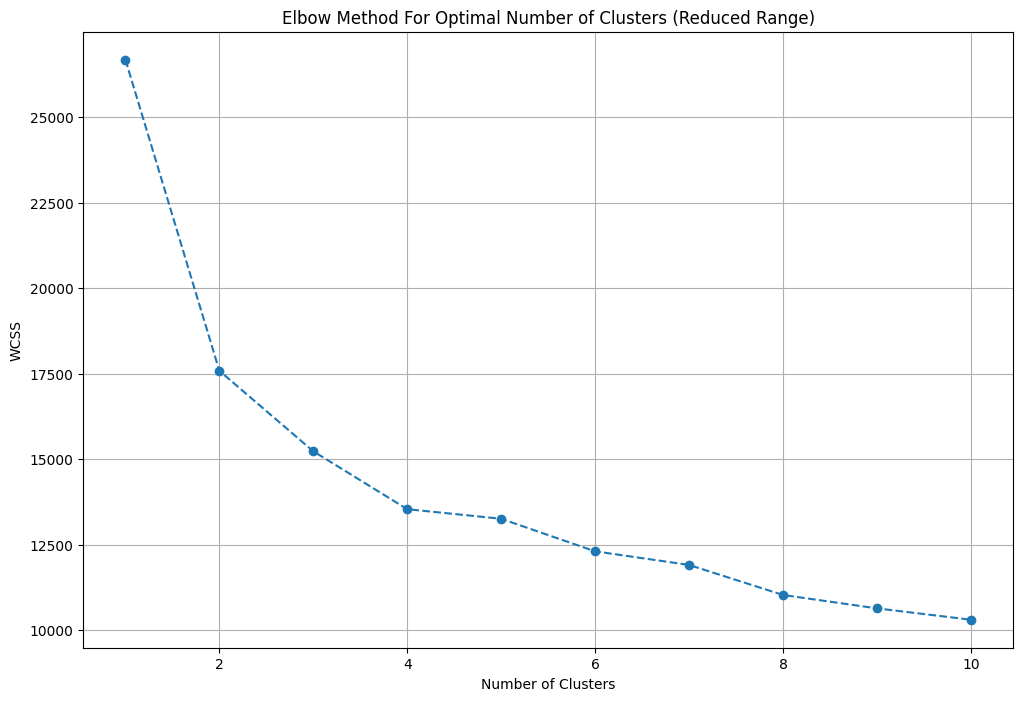

In [77]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [78]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [79]:
df['luxury_score'] = luxury_score

In [80]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,house,sare crescent parc royal greens phase 1,sector 92,0.85,4877.0,1743.0,Built Up area: 1743 (161.93 sq.m.),4,4,3,not available,4.0,NaN,Undefined,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. Sarkar Clinic', 'Vijay Petrol Pump', 'HP Petrol Pump', 'Indian Oil', 'Essar Petrol Pump', 'Garhi harsaru junction railway station']","['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN,NaN,1743.0,NaN,0,0,0,0,0,0,[],0
1,flat,sare green parc phase 3,sector 92,1.08,5150.0,2097.0,Super Built up area 2090(194.17 sq.m.),4,4,2,servant room,16.0,NaN,New Property,"['Huda Metro Station', 'Sector Road', 'Delhi-Jaipur Expressway', 'Management Development Institute', 'Ajanta Public School', 'The NorthCap University', 'Fortis Memorial Research Institute', 'Indira Gandhi Intl Airport', 'Signature Towers', 'Crowne Plaza Gurgaon', 'Kingdom of Dreams']",NaN,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']",2090.0,NaN,NaN,0,1,0,0,0,0,"[Security / Fire Alarm, Intercom Facility, Lift(s), Maintenance Staff, Water Storage, Separate entry for servant room, No open drainage around, Bank Attached Property, Visitor Parking, Swimming Pool, Park, Security Personnel, Natural Light, Airy Rooms, Shopping Centre, Fitness Centre / GYM, Waste Disposal, Rain Water Harvesting, Club house / Community Center]",107
2,house,unitech uniworld resorts,sector 33,8.00,11428.0,7000.0,Plot area 7000(650.32 sq.m.),4,4,3+,"pooja room,servant room,study room,store room",2.0,West,Old Property,"['Rajiv Chowk Mosque', 'Icici bank ATM', 'Standard chartered ATM', 'Samvit Health Care', 'Airforce Hospital', 'Medanta', ""DR AKRAM JAWED'S THE UPPER LIMB CLINIC"", 'Sukhmani Hospital Pvt. Ltd', 'Vaishnavi Nursing Home', 'Best Urologist Atcomplete Family Clinic', 'Ayushman Hospital And Trauma Centre', 'Park Hospital Gurgaon', 'Wellness Eye Centre', 'Neelkanth Health Care', 'Dr. Aruna Kalra', 'Vishesh Dental', 'Smile Plus Dental Clinic', 'Dr. Anuj Sharma', 'Dr. Naresh Pandita', 'Bansal Medicare and Maternity Centre', 'Pushpanjali Hospital Gurgaon', 'Shri Ram Dental Clinic', 'Sunrise Hospital Gurgaon', 'Meher Clinic', 'Rajendra Hospital', 'Pushpanjali Hospital', 'Sai Dental Clinic', 'Nutan Dental Hospital', 'Parmar Dental Clinic & Lab', 'Road and Traffic Authority', 'Gurgaon Election Commission', 'Apollo Pharmacy', 'Gardian Pharmacy', 'Genius', 'India Oil', 'SRS Cinemas', 'SRS Cinemas', 'Hdfc bank', 'Icici bank', 'Hdfc bank', 'KFC', 'Haldiram', ""Domino's Pizza"", ""Nirula's"", 'Kendriya Vidyalaya No.2 Sohna Road', 'Delhi Public School Primary Section']",NaN,"['Private Garden / Terrace', 'False Ceiling Lighting', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Low Density Society', 'Fitness Centre / GYM', 'Club house / Community Center']",NaN,7000.0,NaN,1,1,1,1,0,0,"[Private Garden / Terrace, False Ceiling Lighting, Separate entry for servant room, No open drainage around, Bank Attached Property, Visitor Parking, Swimming Pool, Park, Security Personnel, Internet/wi-fi connectivity, Low Densi

In [81]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [82]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
54,flat,ramsons kshitij,sector 95,0.33,3911.0,844.0,Super Built up area 767(71.26 sq.m.),2,2,1,14.0,South,New Property,767.0,NaN,NaN,0,0,0,0,1,1,79
312,flat,bestech spa signature,sector 81,4.40,12571.0,3500.0,Super Built up area 4200(390.19 sq.m.)Built Up area: 3700 sq.ft. (343.74 sq.m.)Carpet area: 3500 sq.ft. (325.16 sq.m.),4,4,3+,6.0,South-West,New Property,4200.0,3700.00,3500.00,1,1,0,1,1,2,49
2328,flat,vatika lifestyle homes,sector 83,1.15,8214.0,1400.0,Super Built up area 1832(170.2 sq.m.)Carpet area: 1400 sq.ft. (130.06 sq.m.),3,3,1,7.0,South-West,Moderately Old,1832.0,NaN,1400.00,0,0,0,0,0,1,95
1937,flat,experion the heartsong,sector 108,1.68,8387.0,2003.0,Super Built up area 2003(186.08 sq.m.)Built Up area: 1338.29 sq.ft. (124.33 sq.m.)Carpet area: 986.41 sq.ft. (91.64 sq.m.),3,3,3+,4.0,East,Relatively New,2003.0,1338.29,986.41,1,1,0,0,0,1,86
2574,flat,ireo victory valley,sector 67,3.49,13000.0,2685.0,Carpet area: 2452 (227.8 sq.m.),3,3,3,19.0,South-East,Relatively New,NaN,NaN,2452.00,0,1,0,0,0,0,103


In [83]:
df.shape

(3803, 23)

In [84]:
# Create the folder if it doesn't exist
os.makedirs("../data/feature_engineered", exist_ok=True)

df.to_csv("../data/feature_engineered/gurgaon_properties_cleaned_v2.csv", index=False)

print("Feature engineered dataset saved successfully!")

Feature engineered dataset saved successfully!
